# Modélisation du risque de défaut de paiement des titulaires de carte de crédit par apprentissage automatique
## Auteure : Gabrielle Nkouatchet
**Lien du projet GitHub :**  
https://github.com/gabriellenkt-data/credit-risk-analysis 

## Importons les bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

## Chargeons les données

In [3]:
df = pd.read_csv("../data/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Dimensions du jeu de données

In [4]:
df.shape

(30000, 25)

## Types de variables et valeurs manquantes

In [5]:
df.info

<bound method DataFrame.info of           ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0          1    20000.0    2          2         1   24      2      2     -1   
1          2   120000.0    2          2         2   26     -1      2      0   
2          3    90000.0    2          2         2   34      0      0      0   
3          4    50000.0    2          2         1   37      0      0      0   
4          5    50000.0    1          2         1   57     -1      0     -1   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
29995  29996   220000.0    1          3         1   39      0      0      0   
29996  29997   150000.0    1          3         2   43     -1     -1     -1   
29997  29998    30000.0    1          2         2   37      4      3      2   
29998  29999    80000.0    1          3         1   41      1     -1      0   
29999  30000    50000.0    1          2         1   46      0      0      0   

       PAY_4  ...  

## Statistique descriptives


In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## Structure des variables

In [7]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

## Distribution de la variable cible (défaut de paiement)

In [8]:
df["default.payment.next.month"].value_counts()
df["default.payment.next.month"].value_counts(normalize=True)

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

### Interprétation

Le jeu de données contient 30 000 observations et 25 variables. La variable cible indique qu’environ 22,12 % des clients sont en situation de défaut de paiement le mois suivant, contre 77,88 % qui ne présentent pas de défaut.

Cette distribution révèle un déséquilibre modéré des classes, ce qui constitue un enjeu important pour la modélisation prédictive. En effet, un modèle naïf pourrait prédire majoritairement la classe dominante (non-défaut) et obtenir une accuracy élevée sans réellement bien détecter les cas de défaut.

## Analyse descriptive de la limite de crédit (LIMIT_BAL)

In [11]:
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

## Graphique de distribution de la limite de crédit

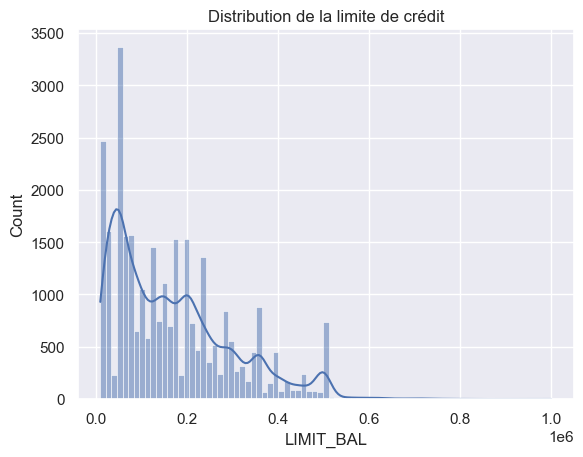

In [12]:
sns.histplot(df["LIMIT_BAL"], kde=True)
plt.title("Distribution de la limite de crédit")
plt.show()

### Interprétation

La limite de crédit moyenne des clients est d’environ 167 484, tandis que la médiane est de 140 000. L’écart-type relativement élevé (129 747) indique une forte dispersion des limites de crédit entre les clients.

La valeur maximale atteint 1 000 000, ce qui suggère la présence de clients à très haute capacité de crédit, potentiellement atypiques par rapport à la majorité de l’échantillon.

La distribution semble asymétrique vers la droite indiquant une présence de valeurs élevées, ce qui pourrait influencer la modélisation et justifier une attention particulière aux valeurs extrêmes.

## Relation entre la limite de crédit et le défaut de paiement

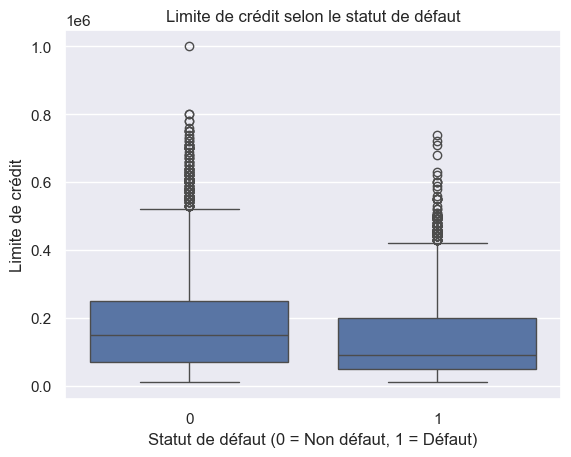

In [13]:
sns.boxplot(
    x="default.payment.next.month",
    y="LIMIT_BAL",
    data=df
)

plt.title("Limite de crédit selon le statut de défaut")
plt.xlabel("Statut de défaut (0 = Non défaut, 1 = Défaut)")
plt.ylabel("Limite de crédit")
plt.show()

### Interprétation

Le graphique en boîte met en évidence une différence notable entre les limites de crédit des clients en défaut et ceux qui ne le sont pas.

La médiane de la limite de crédit est plus élevée pour les clients n’ayant pas fait défaut, tandis que les clients en défaut présentent des limites de crédit généralement plus faibles. De plus, la dispersion des limites est plus importante chez les clients non en défaut, avec davantage de valeurs élevées et de valeurs extrêmes.

Ces observations suggèrent qu’une limite de crédit plus faible pourrait être associée à un risque accru de défaut de paiement. La variable LIMIT_BAL nous apparaît ainsi comme un facteur explicatif pertinent dans la modélisation du risque de crédit.

## Analyse de l’historique de paiement des clients

In [14]:
df["PAY_0"].value_counts().sort_index()

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

## Relation entre le statut de paiement récent et le défaut

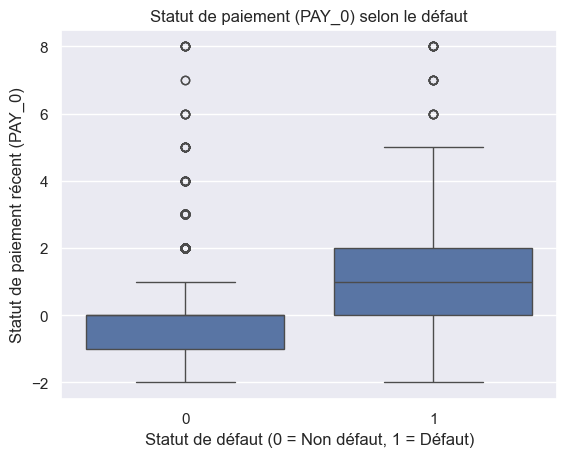

In [15]:
sns.boxplot(
    x="default.payment.next.month",
    y="PAY_0",
    data=df
)

plt.title("Statut de paiement (PAY_0) selon le défaut")
plt.xlabel("Statut de défaut (0 = Non défaut, 1 = Défaut)")
plt.ylabel("Statut de paiement récent (PAY_0)")
plt.show()

## Moyenne par groupe

In [18]:
df.groupby("default.payment.next.month")["PAY_0"].mean()

default.payment.next.month
0   -0.211222
1    0.668174
Name: PAY_0, dtype: float64

### Interprétation

La variable PAY_0 représente le statut de paiement le plus récent. La majorité des clients présentent un statut de paiement normal (0) ou à jour (-1), tandis qu’une proportion plus réduite affiche des retards supérieurs à un mois.

L’analyse par groupe montre une différence marquée entre les clients en défaut et ceux qui ne le sont pas. La moyenne de PAY_0 est négative pour les clients sans défaut (-0,21), indiquant un comportement de paiement globalement régulier. En revanche, les clients en défaut présentent une moyenne positive (0,67), ce qui traduit la présence de retards récents.

Cette variable semble donc fortement associée au risque de défaut et constitue probablement un prédicteur majeur dans la modélisation du risque de crédit.

## Analyse du montant facturé le mois précédent (BILL_AMT1)

In [19]:
df["BILL_AMT1"].describe()

count     30000.000000
mean      51223.330900
std       73635.860576
min     -165580.000000
25%        3558.750000
50%       22381.500000
75%       67091.000000
max      964511.000000
Name: BILL_AMT1, dtype: float64

### Interprétation

Le montant facturé moyen le mois précédent est d’environ 51 223, avec une médiane de 22 381. La différence notable entre la moyenne et la médiane, ainsi que l’écart-type élevé, suggèrent une distribution asymétrique vers la droite.

La présence d’un maximum très élevé (964 511) indique l’existence de clients présentant des montants facturés particulièrement importants, susceptibles d’influencer la distribution globale.

Par ailleurs, certaines valeurs négatives sont observées, ce qui peut refléter des ajustements comptables ou des crédits appliqués aux comptes clients.

Ces éléments montrent que la variable BILL_AMT1 présente une forte variabilité et pourrait jouer un rôle significatif dans l’évaluation du risque de défaut.

#### Distribution graphique

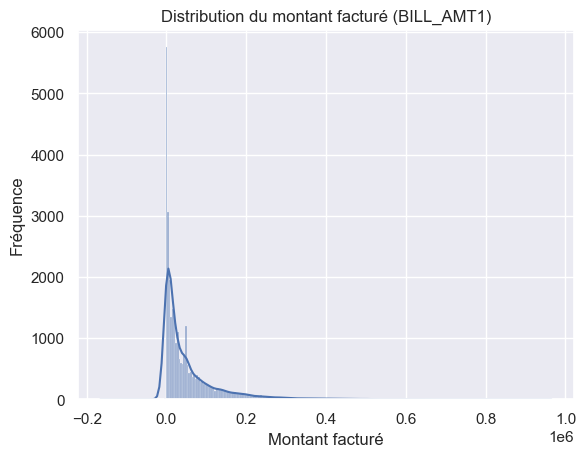

In [20]:
sns.histplot(df["BILL_AMT1"], kde=True)
plt.title("Distribution du montant facturé (BILL_AMT1)")
plt.xlabel("Montant facturé")
plt.ylabel("Fréquence")
plt.show()

### Relation avec le défaut

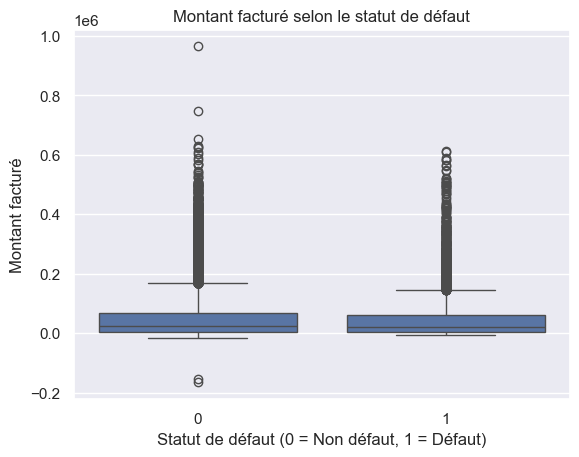

In [21]:
sns.boxplot(
    x="default.payment.next.month",
    y="BILL_AMT1",
    data=df
)

plt.title("Montant facturé selon le statut de défaut")
plt.xlabel("Statut de défaut (0 = Non défaut, 1 = Défaut)")
plt.ylabel("Montant facturé")
plt.show()

### Interprétation

La comparaison des montants facturés selon le statut de défaut montre que les distributions des deux groupes sont relativement similaires. Les médianes sont proches et les deux groupes présentent une forte dispersion ainsi que de nombreuses valeurs extrêmes.

Contrairement à la variable PAY_0, la différence entre clients en défaut et non en défaut est moins marquée pour le montant facturé seul. Cela suggère que le niveau de facture mensuelle, pris isolément, ne constitue pas un indicateur aussi discriminant du risque de défaut.

Toutefois, combinée à d’autres variables comportementales (comme les retards de paiement), cette variable pourrait contribuer à améliorer la performance prédictive du modèle.

## Analyse de l’âge des clients (AGE)

In [22]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

### Interprétation

L’âge moyen des clients est d’environ 35 ans, avec une médiane proche (34 ans), ce qui suggère une distribution relativement équilibrée.

La majorité des clients se situent entre 28 et 41 ans, indiquant une population principalement composée d’adultes actifs. Les valeurs minimales et maximales observées (21 à 79 ans) restent cohérentes et ne semblent pas indiquer d’anomalies majeures.

Cette variable démographique pourrait influencer le comportement financier, notamment en lien avec la stabilité des revenus et la gestion du crédit.

### Distribution

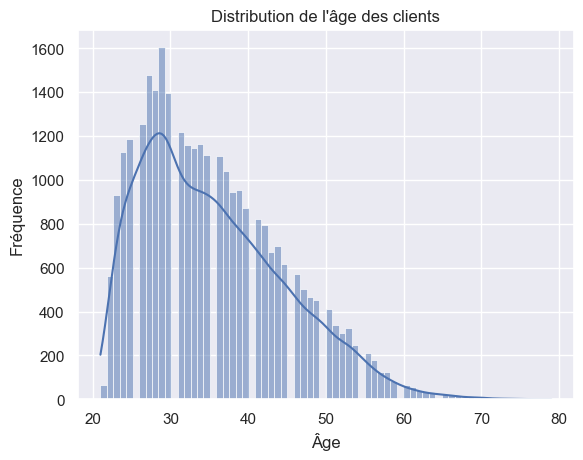

In [23]:
sns.histplot(df["AGE"], kde=True)
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

### Relation avec défaut

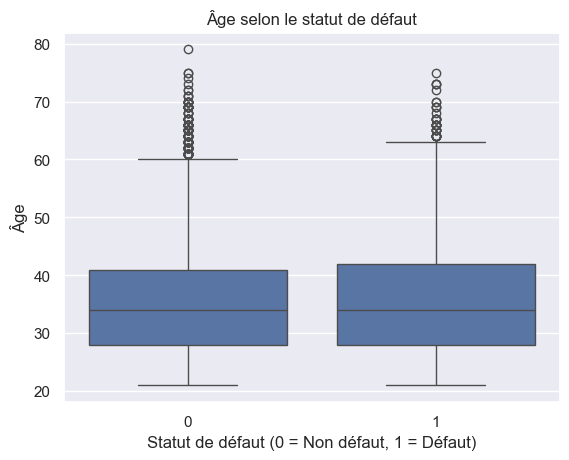

In [24]:
sns.boxplot(
    x="default.payment.next.month",
    y="AGE",
    data=df
)

plt.title("Âge selon le statut de défaut")
plt.xlabel("Statut de défaut (0 = Non défaut, 1 = Défaut)")
plt.ylabel("Âge")
plt.show()

### Interprétation

La comparaison des distributions d’âge entre les clients en défaut et ceux qui ne le sont pas montre des différences relativement limitées.

Les médianes des deux groupes sont proches, et la dispersion est similaire. Bien que les clients en défaut semblent légèrement plus âgés en moyenne, l’écart reste modéré.

Contrairement aux variables comportementales comme PAY_0, l’âge ne paraît pas constituer un facteur discriminant majeur pris isolément. Toutefois, combinée à d’autres variables financières et comportementales, cette variable pourrait contribuer à affiner la modélisation du risque de crédit.

## Préparation des données pour la modélisation

In [35]:
X = df.drop(["default.payment.next.month", "ID"], axis=1)
y = df["default.payment.next.month"]

X.shape, y.shape

((30000, 23), (30000,))

### Interprétation

La variable cible est `default.payment.next.month` et les 23 autres variables excluant la colonne ID sont utilisées comme prédicteurs.

### Séparation des données en ensembles d’entraînement et de test

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((21000, 23), (9000, 23), (21000,), (9000,))

### Interprétation

Les données ont été divisées en un ensemble d'entraînement (70 %) et un ensemble de test (30 %).

L’option `stratify=y` a été utilisée afin de conserver la proportion initiale de cas de défaut dans les deux ensembles, ce qui est particulièrement important en présence d’un déséquilibre des classes comme c'est notre cas ici (22 % de défaut).

## Modèle 1 : Régression logistique (baseline)

In [37]:
# Standardisons les données

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Entraînement du modèle

In [38]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### Prédictions sur l’ensemble de test

In [39]:
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

### Évaluation des performances du modèle

In [40]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred_log))

print("AUC :", roc_auc_score(y_test, y_proba_log))

confusion_matrix(y_test, y_pred_log)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7009
           1       0.70      0.24      0.35      1991

    accuracy                           0.81      9000
   macro avg       0.76      0.60      0.62      9000
weighted avg       0.79      0.81      0.77      9000

AUC : 0.7150297683562334


array([[6805,  204],
       [1521,  470]])

### Interprétation des performances

La régression logistique obtient une accuracy globale de 81 %. Toutefois, cette métrique doit être interprétée avec prudence en raison du déséquilibre des classes (22 % de défaut).

Le modèle détecte efficacement les clients sans défaut (recall de 97 %), mais présente une capacité limitée à identifier les clients en défaut (recall de 24 %). Cela signifie qu’une proportion importante de clients à risque n’est pas correctement détectée.

L’AUC de 0,71 indique une capacité de discrimination acceptable mais perfectible.

Dans un contexte bancaire, le coût d’un faux négatif, consistant à ne pas détecter un client à risque, est généralement plus élevé qu’un faux positif. Ainsi, l’amélioration du recall pour la classe "défaut" constitue un enjeu majeur.

Le modèle semble donc privilégier la prédiction de la classe majoritaire, ce qui est typique en présence de données déséquilibrées.

## Modèle 2 : Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

### Prédictions du modèle Random Forest

In [42]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

### Évaluation des performances du modèle Random Forest

In [43]:
print(classification_report(y_test, y_pred_rf))

print("AUC :", roc_auc_score(y_test, y_proba_rf))

confusion_matrix(y_test, y_pred_rf)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      7009
           1       0.63      0.36      0.46      1991

    accuracy                           0.81      9000
   macro avg       0.74      0.65      0.67      9000
weighted avg       0.79      0.81      0.79      9000

AUC : 0.7587901441778345


array([[6591,  418],
       [1265,  726]])

### Comparaison des modèles

La Random Forest améliore significativement la détection des cas de défaut par rapport à la régression logistique. Le recall pour la classe "défaut" passe de 24 % à 36 %, réduisant ainsi le nombre de faux négatifs.

On constate que l’AUC augmente également de 0,71 à 0,76, ce qui indique une meilleure capacité de discrimination globale.

Dans un contexte bancaire, où le coût d’un faux négatif est élevé, la Random Forest apparaît plus adaptée à la prédiction du risque de crédit.

### Importance des variables (Random Forest)

In [44]:
feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Variable,Importance
5,PAY_0,0.100522
4,AGE,0.065916
0,LIMIT_BAL,0.060327
11,BILL_AMT1,0.059979
12,BILL_AMT2,0.053810
13,BILL_AMT3,0.051656
16,BILL_AMT6,0.050712
14,BILL_AMT4,0.050476
17,PAY_AMT1,0.050265
15,BILL_AMT5,0.049406


### Importance des variables

L’analyse de l’importance des variables dans la Random Forest confirme que le statut de paiement récent (PAY_0) constitue le facteur prédictif le plus déterminant.

Les variables financières telles que LIMIT_BAL et BILL_AMT1 apparaissent également contributives, bien que dans une moindre mesure. L’âge (AGE) présente une importance modérée, suggérant qu’il peut jouer un rôle indirect dans la modélisation.

La suppression de la variable ID, qui correspondait à un identifiant unique sans signification économique, n’a pas modifié substantiellement les performances du modèle, confirmant qu’elle ne contribuait pas réellement à la prédiction.

### Courbe ROC du Random Forest

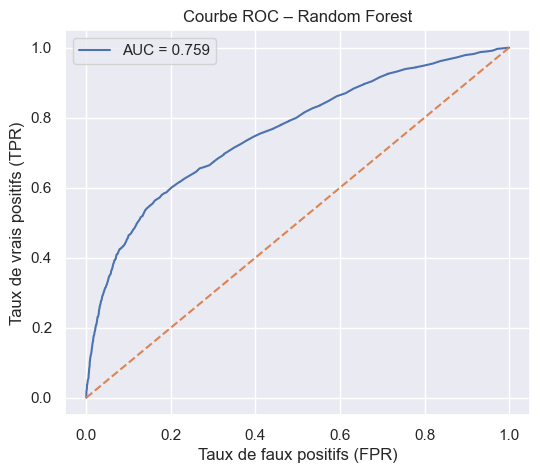

In [45]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_rf):.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # ligne aléatoire

plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC – Random Forest")
plt.legend()
plt.show()

### Interprétation de la courbe ROC

La courbe ROC montre une séparation claire au-dessus de la diagonale correspondant à un modèle aléatoire. La forme bien incurvée vers le coin supérieur gauche indique une capacité de discrimination satisfaisante.

L’aire sous la courbe (AUC) est de 0,759, ce qui signifie que le modèle possède environ 76 % de probabilité de classer correctement un client en défaut par rapport à un client sans défaut.

Cette performance est cohérente avec les métriques précédentes et confirme que la Random Forest offre une capacité prédictive acceptable dans le cadre de ce projet.

## Limites du modèle

### 1. Déséquilibre des classes

Le jeu de données présente un déséquilibre notable, avec environ 22 % de cas de défaut contre 78 % de non-défaut. Cette configuration peut biaiser les performances du modèle, notamment en favorisant la classe majoritaire.

Malgré l’amélioration apportée par la Random Forest, le recall pour la classe "défaut" reste modéré (36 %), ce qui signifie qu’un nombre significatif de clients à risque n’est pas détecté.

### 2. Variables limitées au contexte fourni

Le modèle repose uniquement sur les variables disponibles dans le jeu de données. Dans un contexte bancaire réel, d’autres facteurs pourraient être intégrés, tels que le revenu, l’historique professionnel ou des données macroéconomiques.

### 3. Interprétabilité partielle

Bien que la Random Forest améliore la performance prédictive, elle est moins interprétable qu’une régression logistique, ce qui peut constituer une limite dans un contexte réglementaire bancaire.

## Perspectives d’amélioration

Plusieurs pistes d’amélioration pourraient être envisagées afin d’optimiser les performances du modèle. Tout d’abord, un ajustement du seuil de décision ou l’utilisation de techniques de gestion du déséquilibre des classes (comme l’attribution de poids différenciés ou le suréchantillonnage) permettrait d’améliorer la détection des cas de défaut. Ensuite, une optimisation plus poussée des hyperparamètres de la Random Forest pourrait accroître la capacité prédictive du modèle. Enfin, la création de nouvelles variables dérivées, telles qu’un ratio d’utilisation du crédit, pourrait enrichir l’information disponible et renforcer la pertinence de la modélisation.

## Conclusion générale

En définitive, ce projet avait pour objectif de prédire le risque de défaut de paiement à partir du jeu de données "Default of Credit Card Clients".

L’analyse exploratoire a permis d’identifier plusieurs variables fortement associées au risque de défaut, notamment le statut de paiement récent (PAY_0), qui apparaît comme le prédicteur le plus déterminant. Les variables financières telles que la limite de crédit et les montants facturés contribuent également à la modélisation, bien que dans une moindre mesure.

La comparaison entre une régression logistique et une Random Forest montre que la Random Forest offre une meilleure capacité de détection des cas de défaut, avec une amélioration notable du recall et de l’AUC (0,76). Toutefois, le modèle reste confronté au défi du déséquilibre des classes, limitant la détection complète des clients à risque.

Dans l’ensemble, les résultats obtenus sont cohérents avec les mécanismes économiques du risque de crédit et démontrent la pertinence des variables comportementales dans la prédiction du défaut. 